In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
import shap
import warnings
warnings.filterwarnings('ignore')



In [2]:
# Cargar datos
file_path = 'C:/Users/maite/OneDrive - UNIR/tfm/dataset/dataset_imputaciones.csv'
data = pd.read_csv(file_path)

In [3]:
data_cleaned = pd.get_dummies(data, columns=['Continent'], drop_first=True)
# Eliminar solo la columna 'CountryCode'
data_cleaned = data_cleaned.drop(columns=["CountryCode"])
data_cleaned.head()

,CountryName,Year,Age dependency ratio (% of working-age population),"Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)",GDP per capita (current US$),"Immunization, DPT (% of children ages 12-23 months)","Life expectancy at birth, total (years)","Mortality caused by road traffic injury (per 100,000 population)","PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",Political Stability and Absence of Violence/Terrorism: Estimate,...,Eating.disorders,Bipolar.disorder,Depression,Anxiety.disorders,Alcohol.use.disorders,PIB,Continent_Americas,Continent_Asia,Continent_Europe,Continent_Oceania
0,Albania,2001.0,58.713611,31.555107,1281.659826,97.0,75.639,14.5,22.366006,0.083183,...,0.134932,0.698912,2.201979,3.364824,1.659040,9.314397,False,False,True,False
1,Albania,2002.0,57.686996,33.334158,1425.124219,98.0,75.890,14.5,22.482785,-0.297719,...,0.137541,0.699501,2.208921,3.370780,1.670158,4.850475,False,False,True,False
2,Albania,2003.0,56.621576,35.390972,1846.120121,97.0,76.142,14.7,22.593449,-0.309780,...,0.140335,0.700114,2.216283,3.376952,1.685102,5.924212,False,False,True,False
3,Albania,2004.0,55.502761,37.557932,2373.581292,97.0,76.376,14.7,22.675923,-0.427260,...,0.143047,0.700683,2.222116,3.382199,1.701433,5.956570,False,False,True,False
4,Albania,2005.0,54.299368,40.067390,2673.787816,98.0,76.621,14.9,22.708130,-0.505048,...,0.145738,0.701136,2.223407,3.385416,1.716585,6.067882,False,False,True,False


In [4]:
# Variables de las enfermedades y el total
target_variables = [
    "Drug.use.disorders", 
    "Schizophrenia", 
    "Eating.disorders", 
    "Bipolar.disorder", 
    "Depression", 
    "Anxiety.disorders", 
    "Alcohol.use.disorders", 
    "Total_Prevalence"
]

Este código genera un heatmap (mapa de calor) que visualiza las correlaciones de las variables numéricas en el dataset con respecto a una variable objetivo (target_column). La visualización se realiza para cada una de las enfermedades en target_variables.

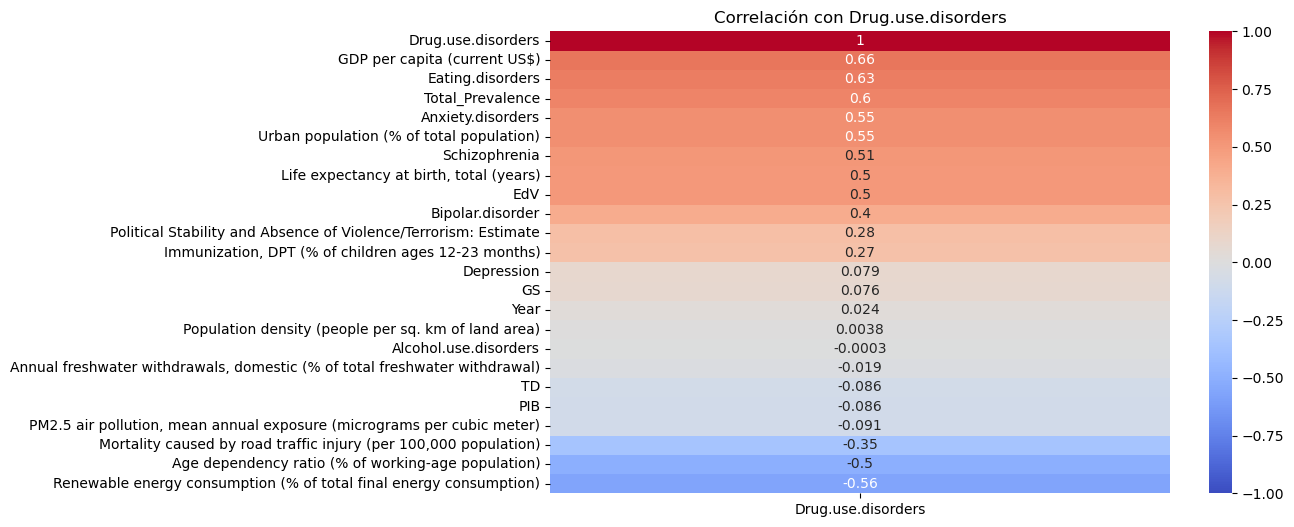

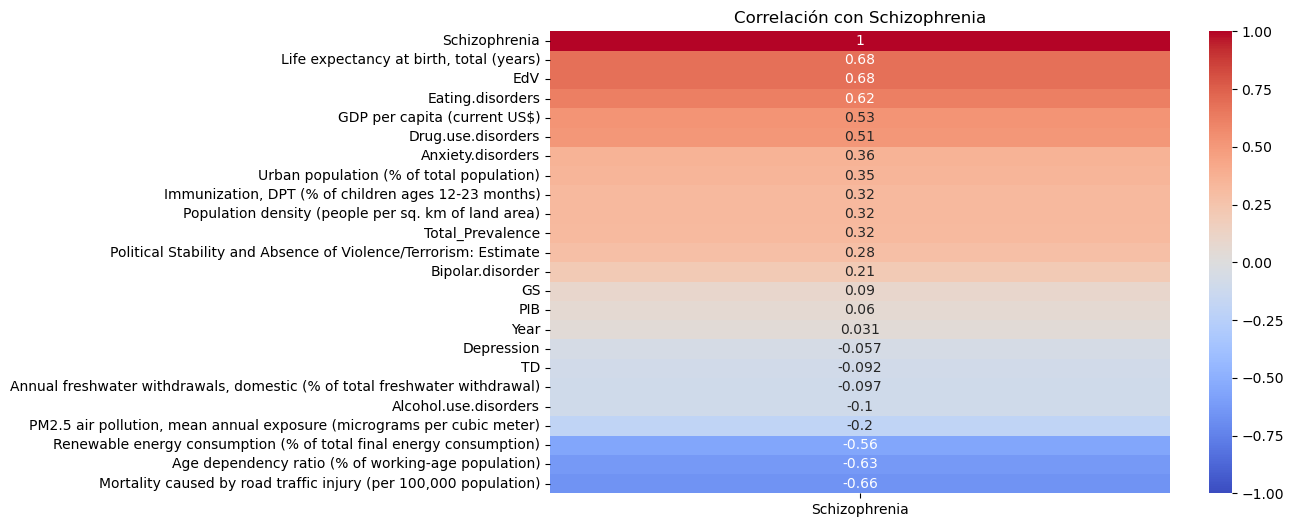

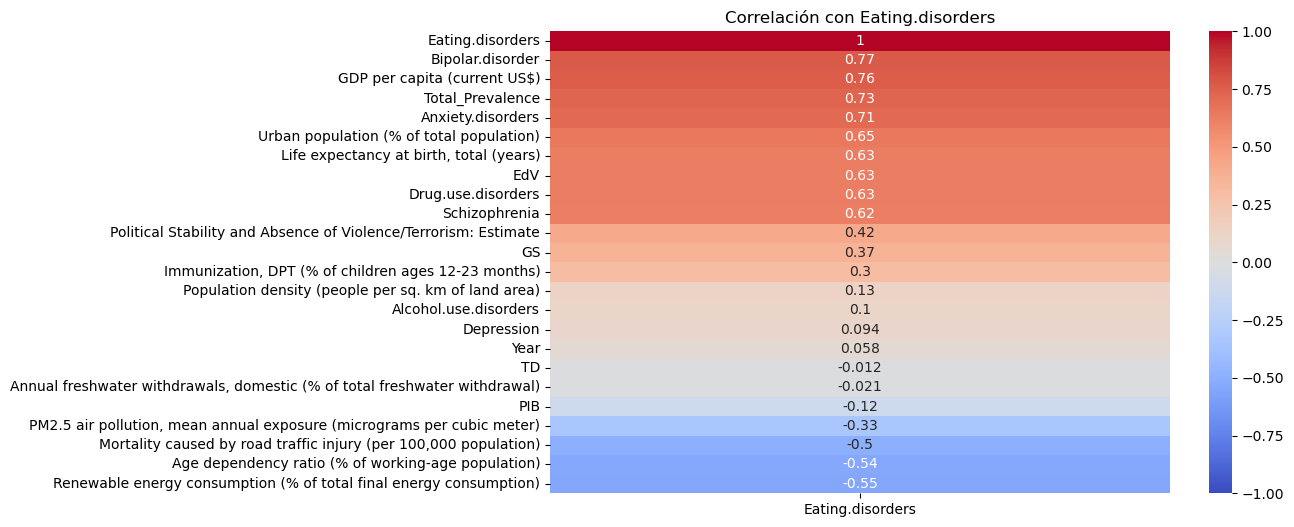

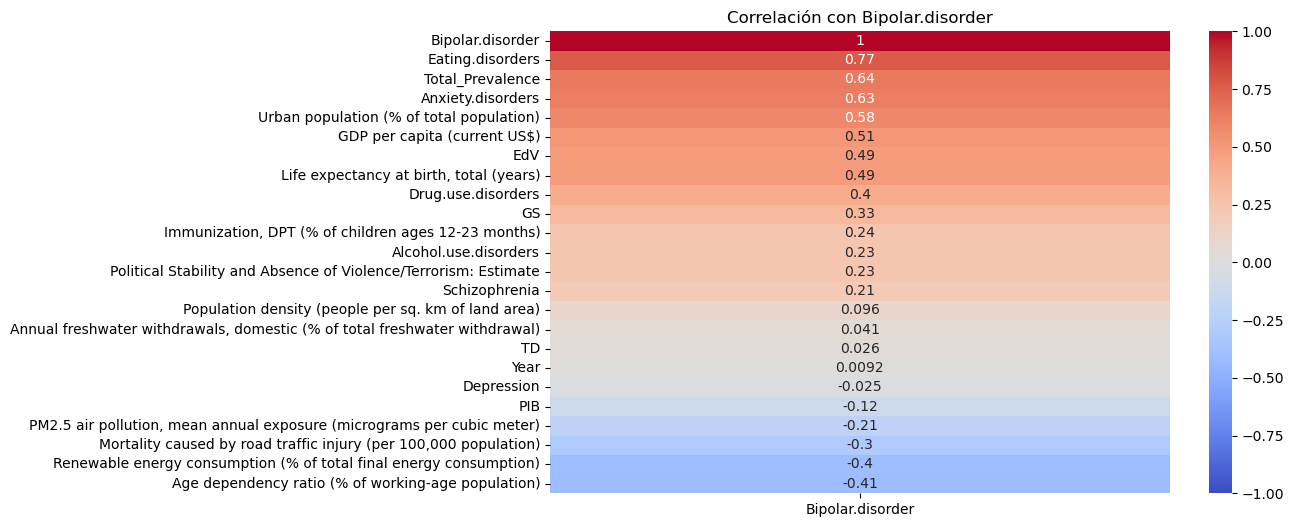

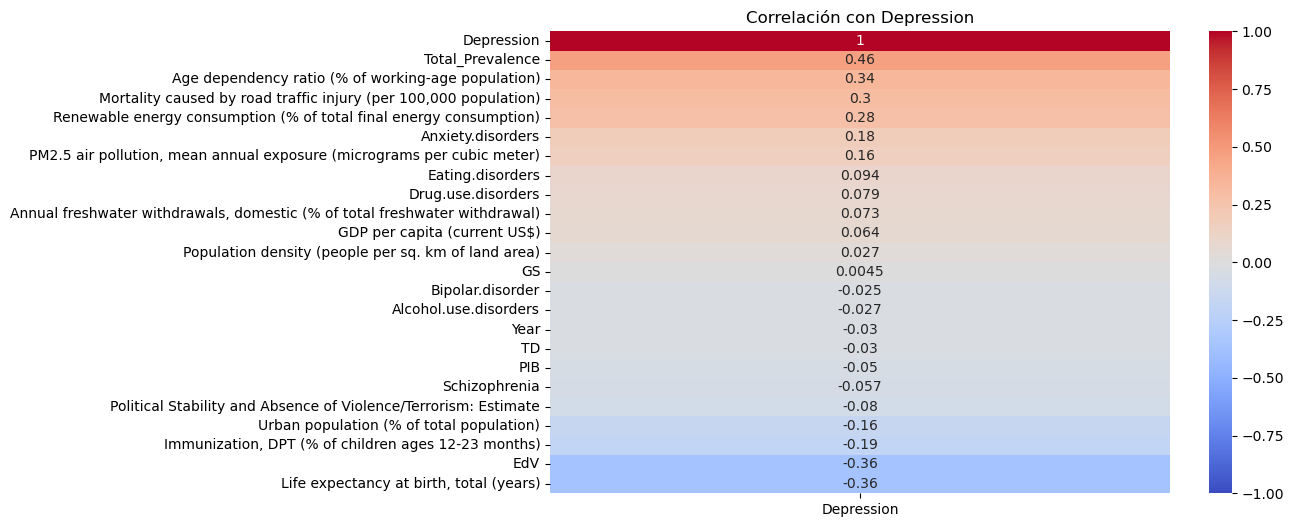

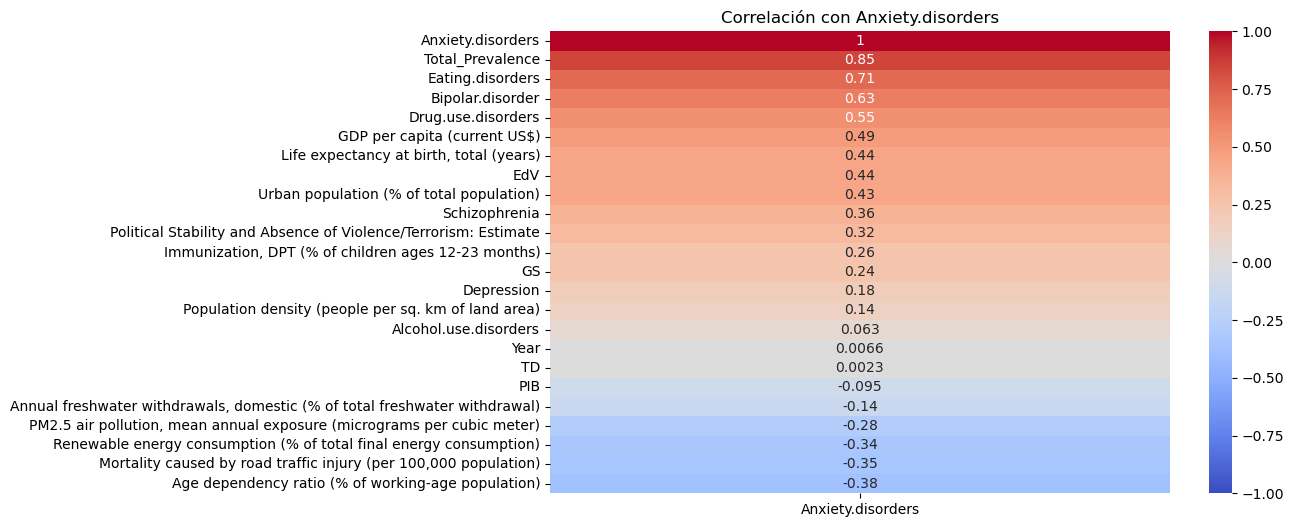

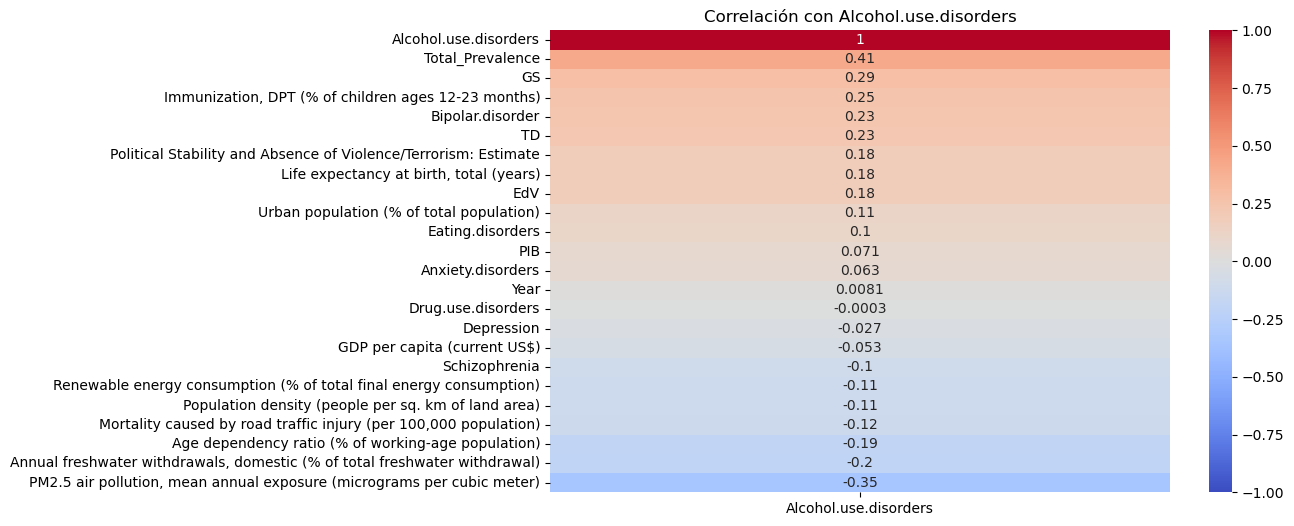

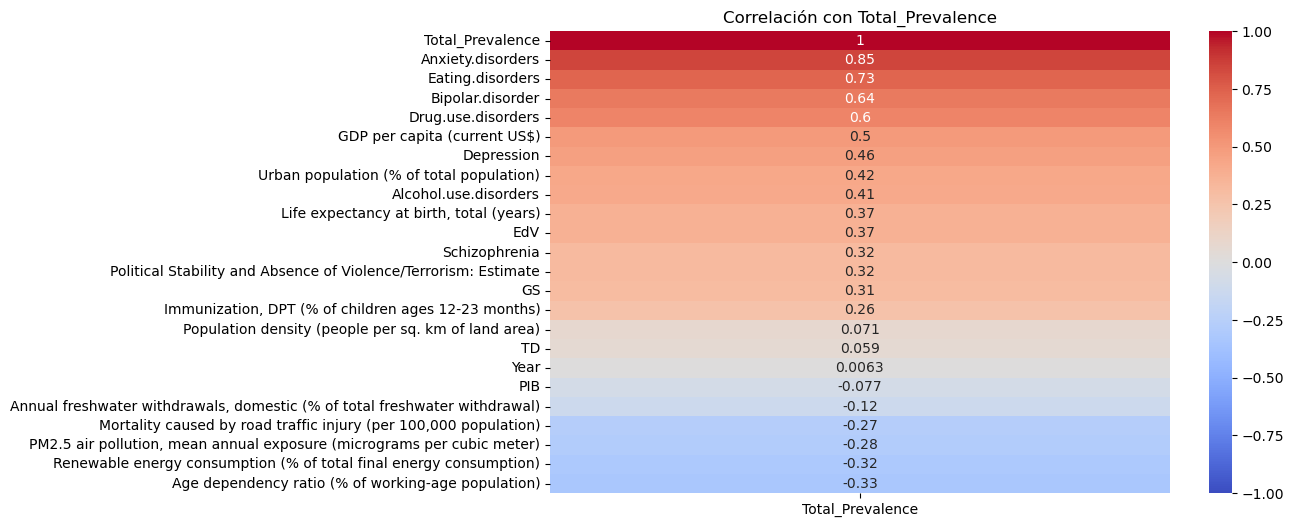

In [5]:
# Función para graficar un heatmap de correlación
def plot_heatmap_of_correlations(df, target_column):
    # Seleccionar solo columnas numéricas
    numeric_df = df.select_dtypes(include=['number'])
    
    # Calcular la matriz de correlación con las columnas numéricas
    correlation_matrix = numeric_df.corr()
    
    # Filtrar las correlaciones con el target específico
    correlation_with_target = correlation_matrix[target_column].sort_values(ascending=False)
    
    # Graficar el heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(correlation_with_target.to_frame(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f'Correlación con {target_column}')
    plt.show()

# Mostrar heatmap de correlación para cada enfermedad
for target in target_variables:
    plot_heatmap_of_correlations(data, target)

En los siguientes heatmap se han exlcluido las variables pertenecientes a las prevalencias de otras enfermedades y Total_prevalence.

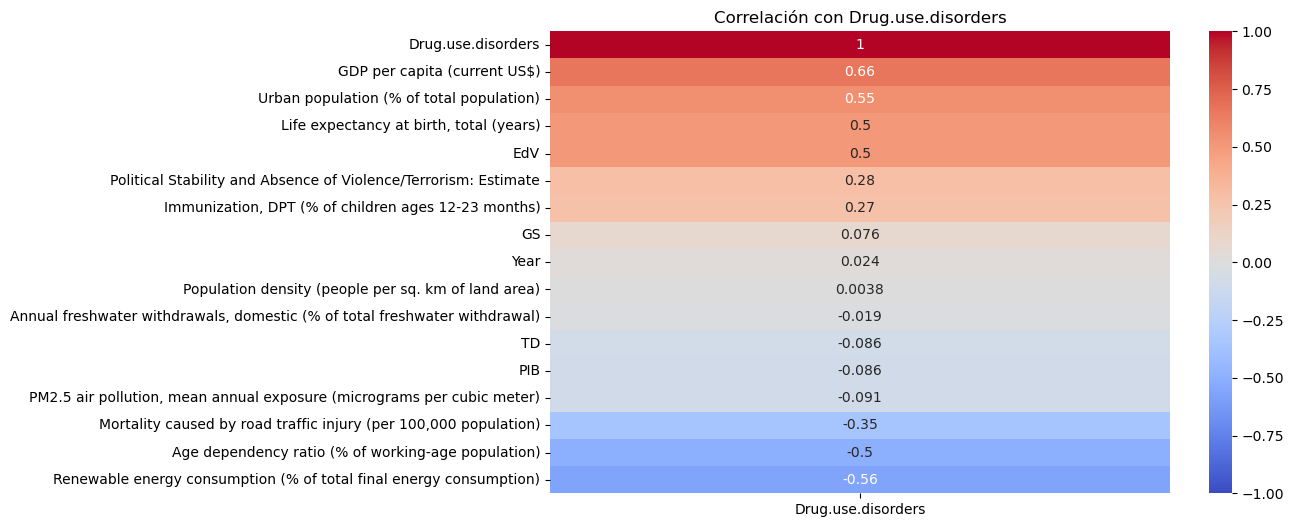

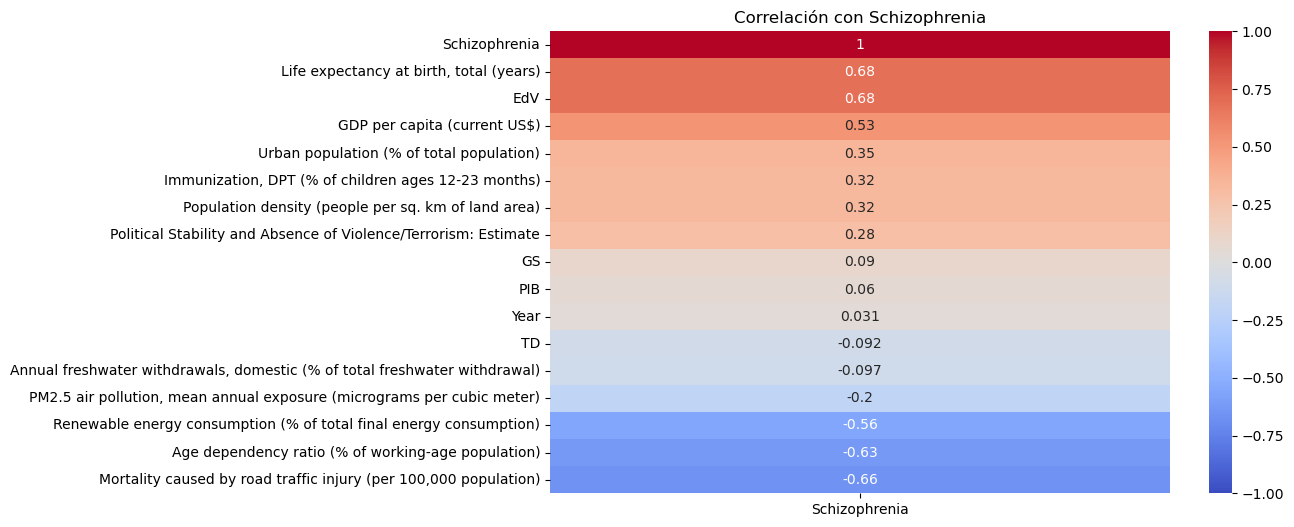

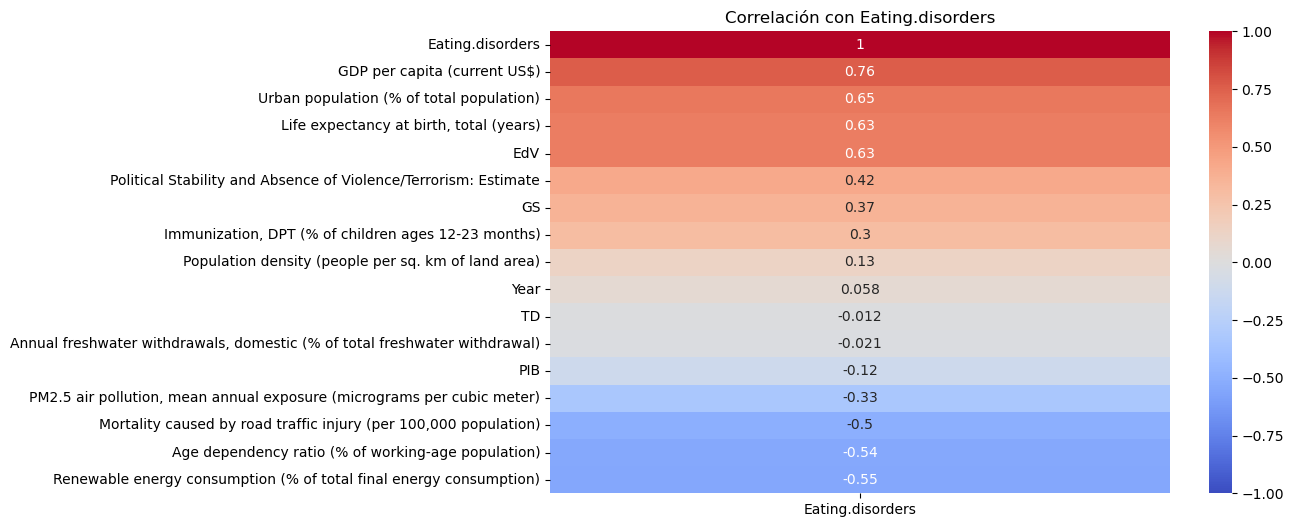

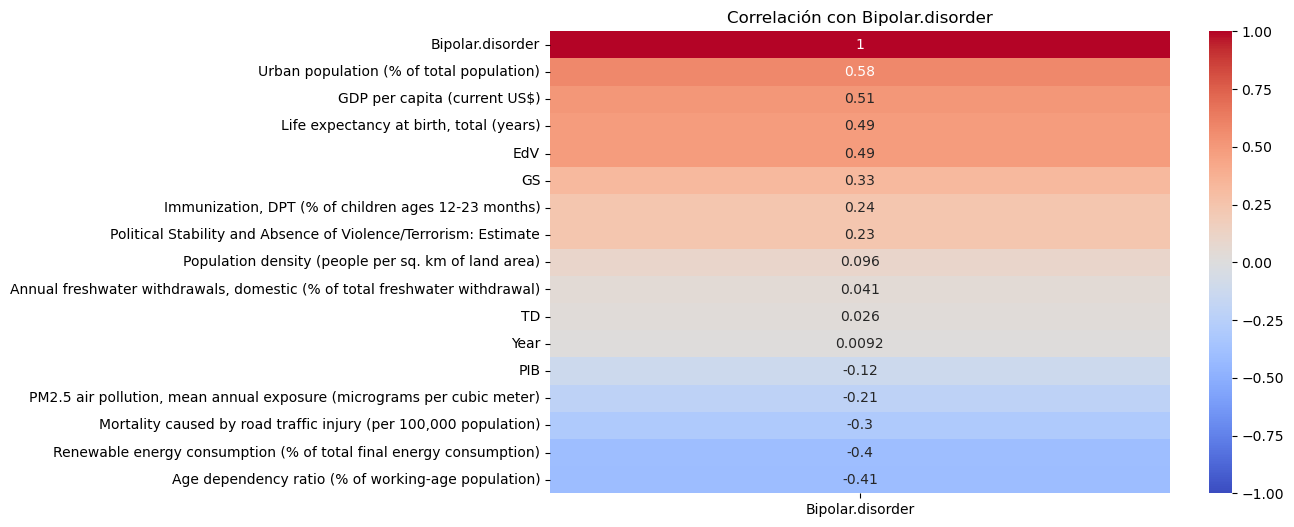

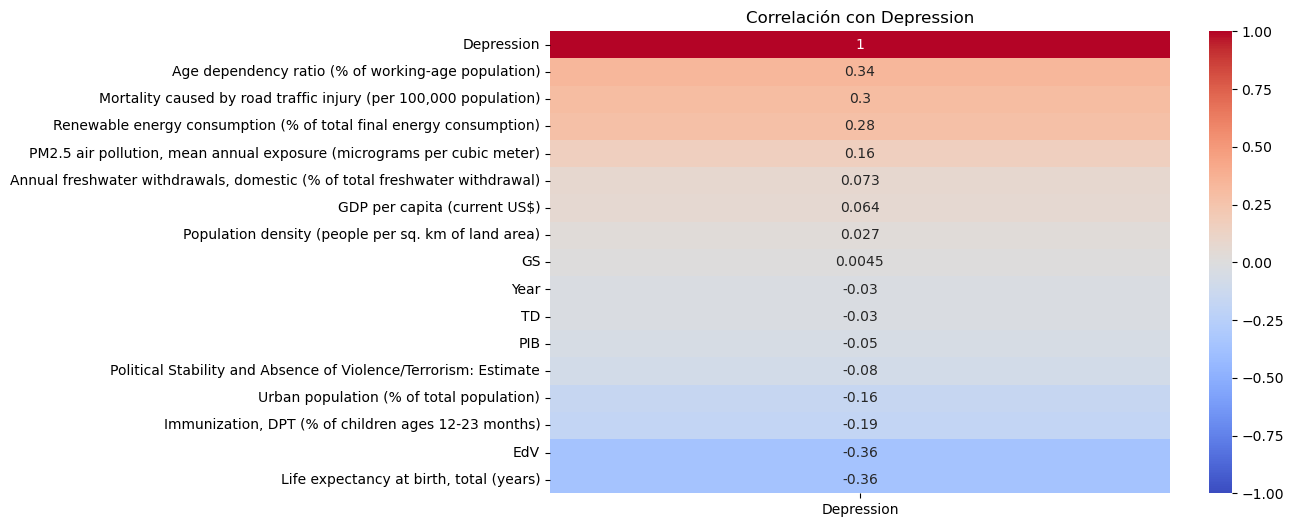

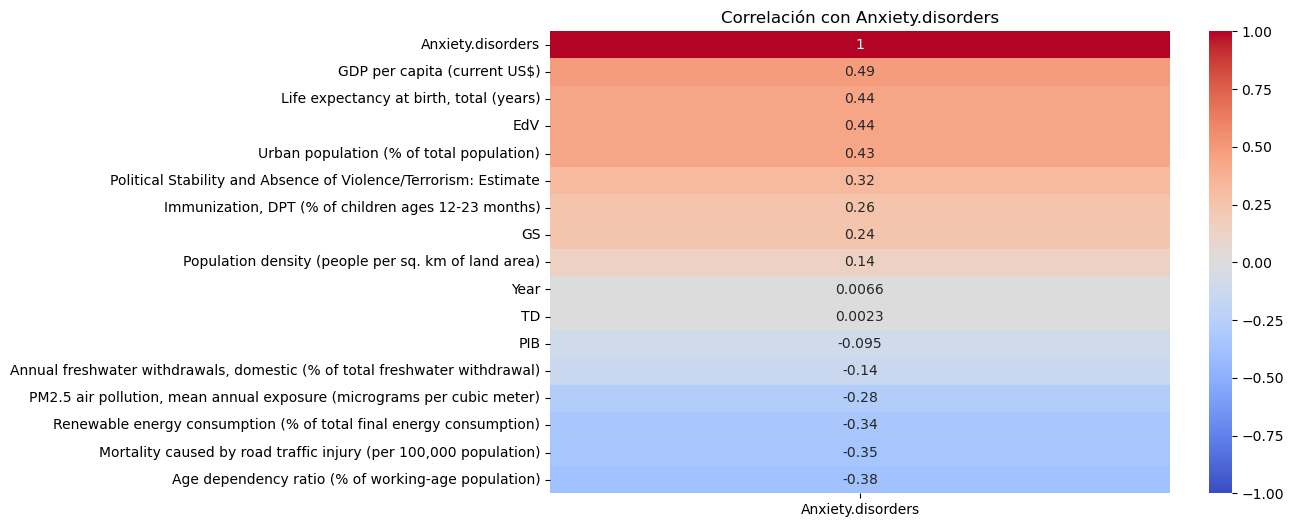

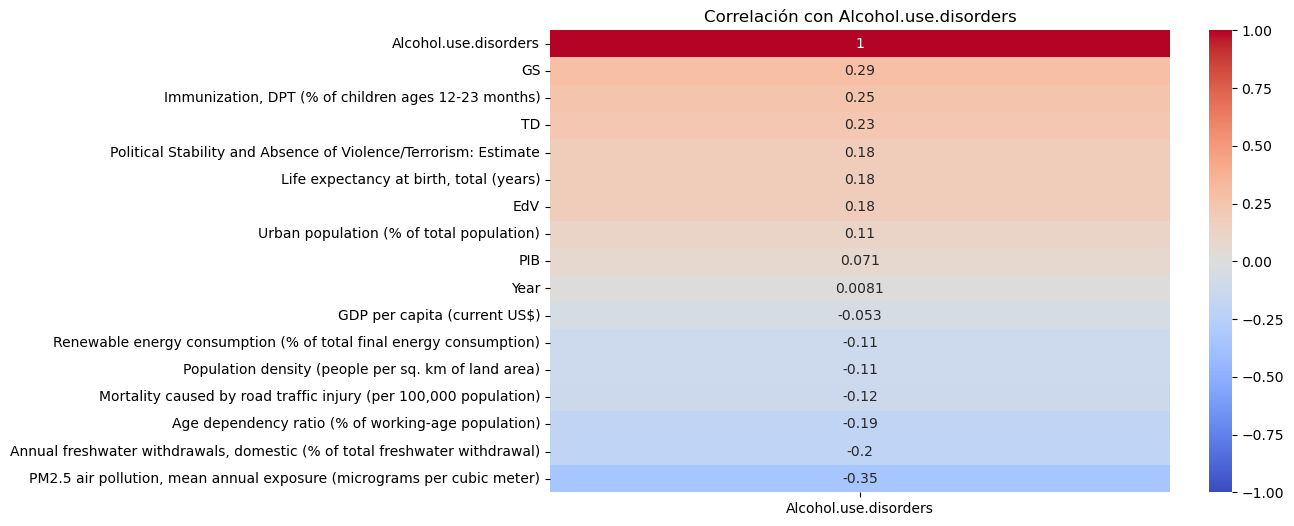

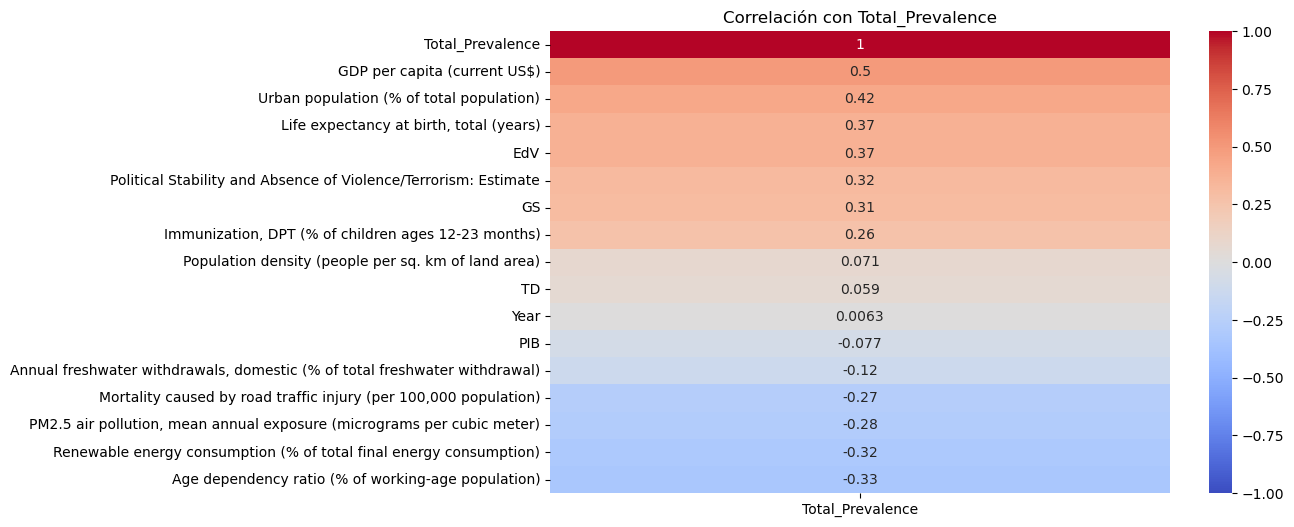

In [6]:
# Función para graficar un heatmap de correlación, excluyendo columnas no deseadas
def plot_heatmap_of_correlations(df, target_column, exclude_columns=None):
    if exclude_columns is None:
        exclude_columns = []
        
    # Asegurarse de no excluir la columna target
    if target_column in exclude_columns:
        exclude_columns.remove(target_column)
        
    # Seleccionar solo columnas numéricas y excluir las columnas no deseadas
    numeric_df = df.select_dtypes(include=['number'])
    numeric_df = numeric_df.drop(columns=exclude_columns, errors='ignore')
    
    # Calcular la matriz de correlación con las columnas numéricas
    correlation_matrix = numeric_df.corr()
    
    # Filtrar las correlaciones con el target específico
    correlation_with_target = correlation_matrix[target_column].sort_values(ascending=False)
    
    # Graficar el heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(correlation_with_target.to_frame(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f'Correlación con {target_column}')
    plt.show()

# Mostrar heatmap de correlación para cada enfermedad, excluyendo Total_Prevalence y otras prevalencias
for target in target_variables:
    exclude_columns = [
        "Drug.use.disorders", "Schizophrenia", "Eating.disorders", 
        "Bipolar.disorder", "Depression", "Anxiety.disorders", 
        "Alcohol.use.disorders", "Total_Prevalence"
    ]
    plot_heatmap_of_correlations(data, target, exclude_columns=exclude_columns)

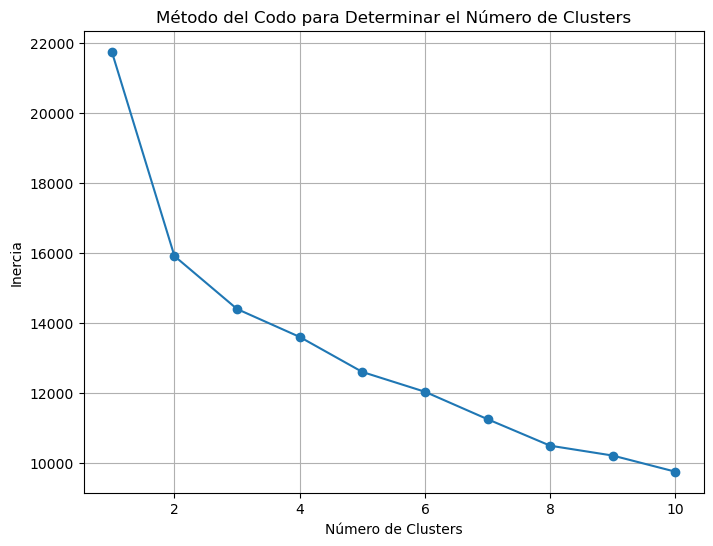

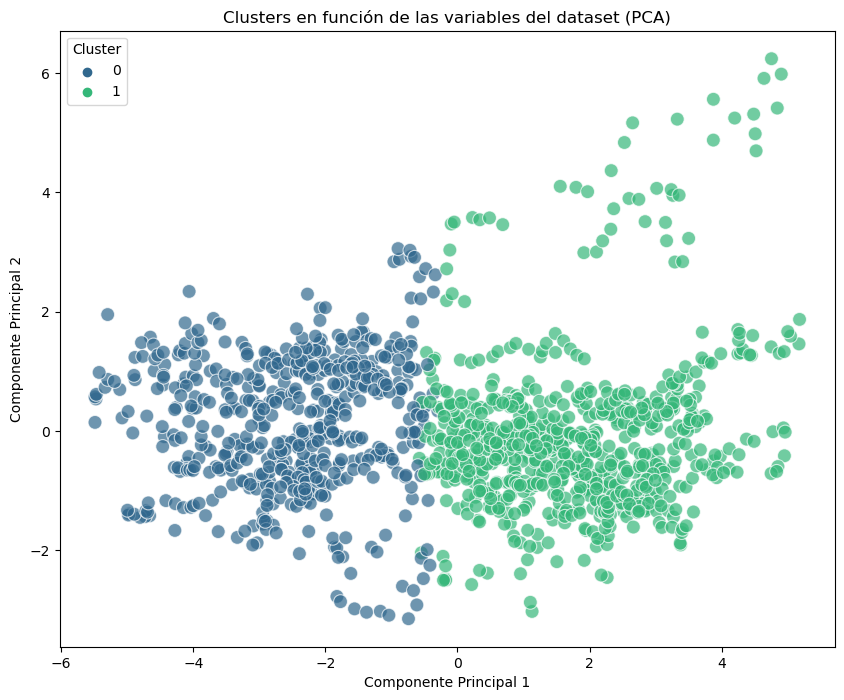

In [7]:
# Selección de las columnas numéricas para el clustering
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

# Excluir las columnas de las prevalencias y 'CountryName' si están en el dataset
columns_for_clustering = [col for col in numerical_columns if col not in target_variables + ['CountryName']]

# Preparamos los datos para el clustering (solo las variables seleccionadas)
data_for_clustering = data[columns_for_clustering]

# Normalizamos los datos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_for_clustering)

# Método del codo para determinar el número óptimo de clusters
inertia = []
k_range = range(1, 11)  # Vamos a probar de 1 a 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# Graficamos el método del codo
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Método del Codo para Determinar el Número de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

# Elegimos el número de clusters basado en el codo, por ejemplo 3 en este caso
n_clusters_optimo = 2  # Cambia esto según el gráfico del codo

# Aplicamos KMeans con el número óptimo de clusters
kmeans = KMeans(n_clusters=n_clusters_optimo, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

# Añadimos la columna de clusters al dataframe
data['Cluster'] = clusters

# Reducimos la dimensionalidad para la visualización (PCA o t-SNE)
pca = PCA(n_components=2)  # Para 2D
data_pca = pca.fit_transform(data_scaled)

# También puedes usar t-SNE si prefieres una visualización más compleja
tsne = TSNE(n_components=2, random_state=42)
data_tsne = tsne.fit_transform(data_scaled)

# Graficamos los clusters con las componentes principales (PCA)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=data['Cluster'], palette="viridis", s=100, alpha=0.7)
plt.title(f"Clusters en función de las variables del dataset (PCA)")
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.show()


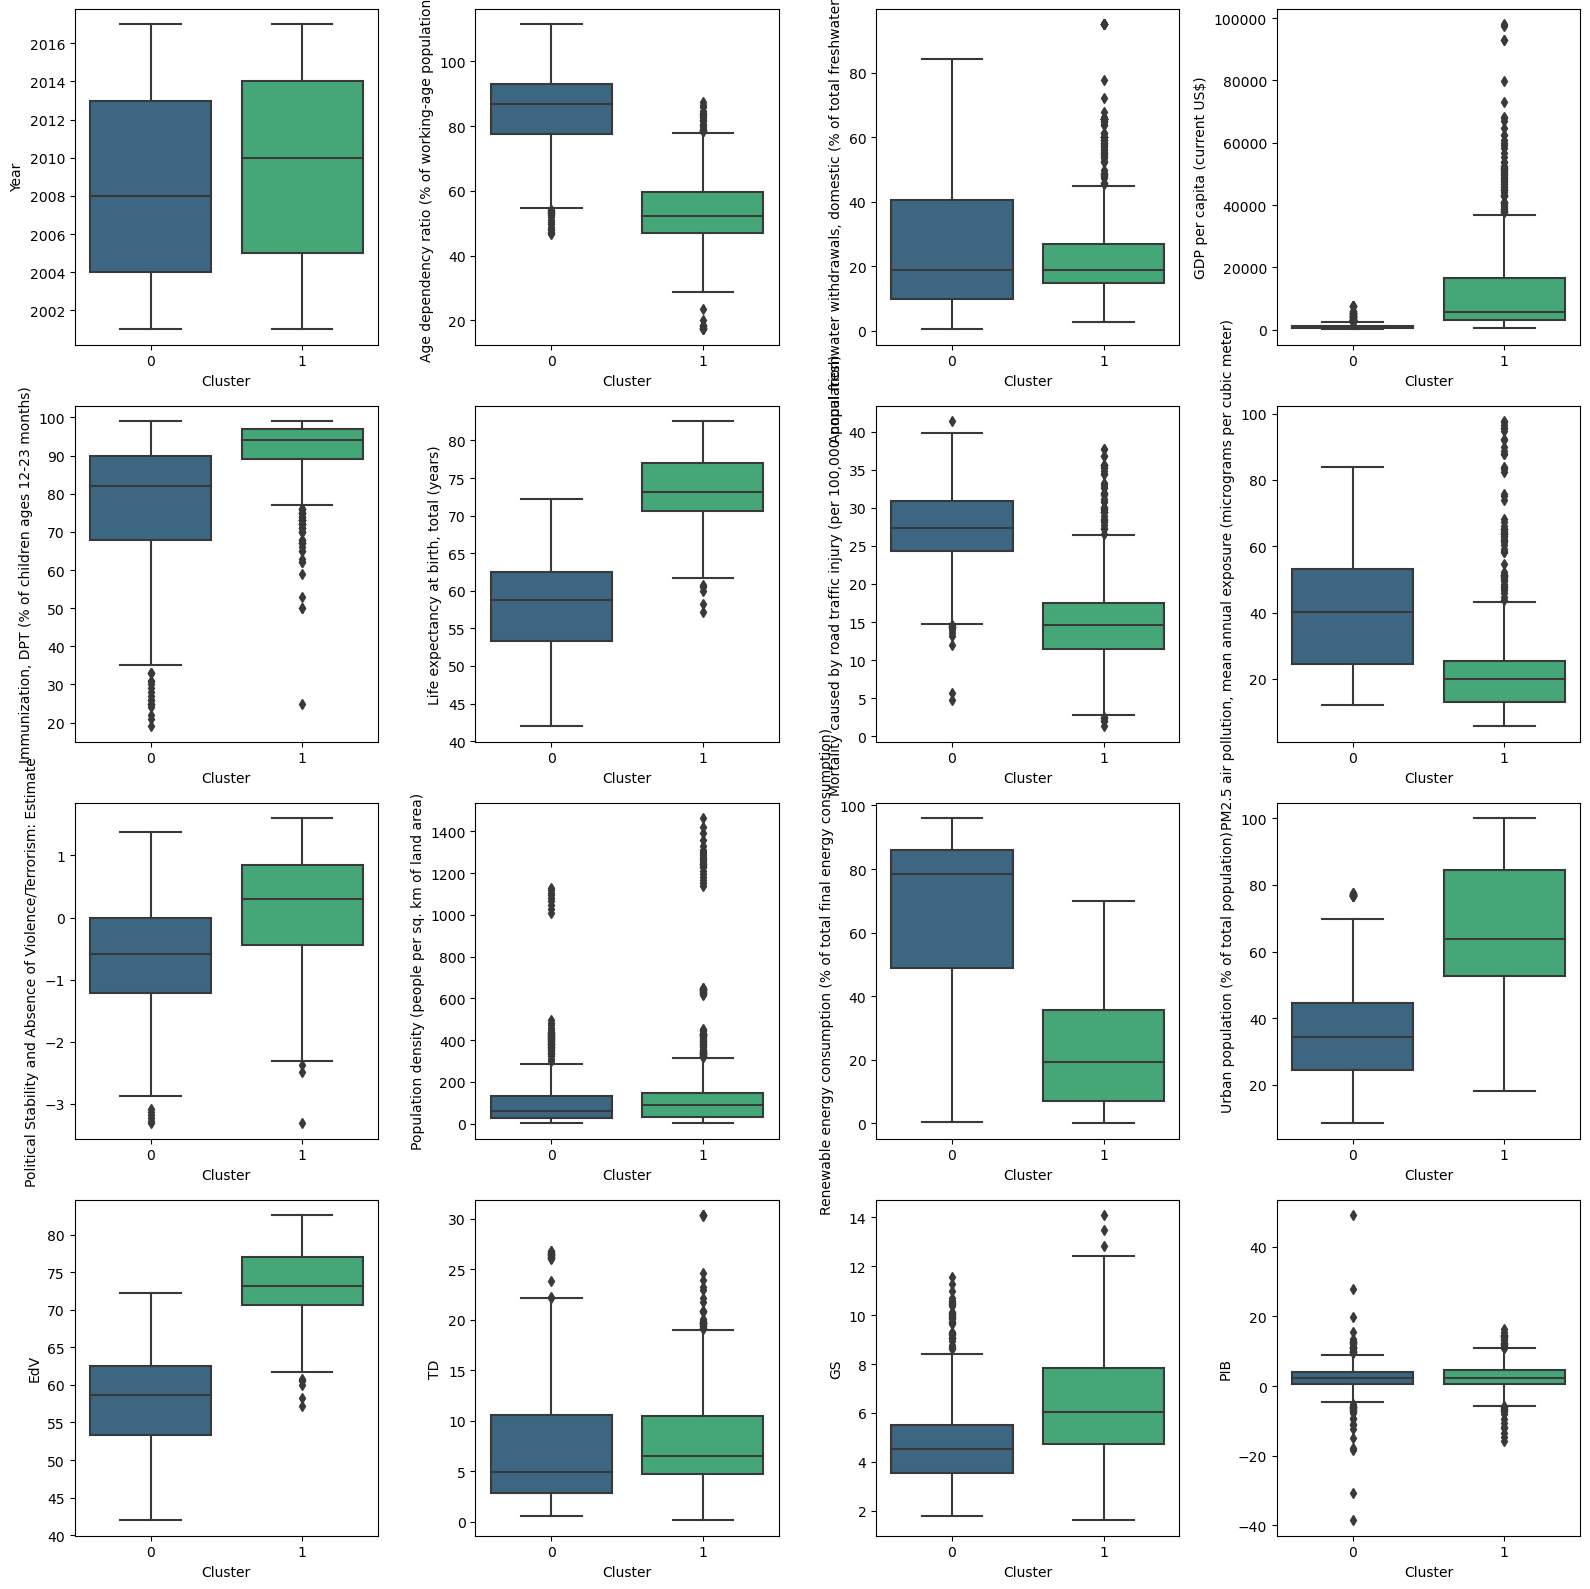

In [8]:
# Visualización de las distribuciones de cada variable por cluster en una matriz 4x4
# Calcular el número de filas necesarias para la cuadrícula (4 columnas)
num_plots = len(columns_for_clustering)
num_rows = (num_plots // 4) + (num_plots % 4 > 0)  # Número de filas necesarias

# Crear una paleta de colores
palette = sns.color_palette("viridis", n_colors=data['Cluster'].nunique())

# Crear la figura para los boxplots
plt.figure(figsize=(16, 4 * num_rows))

# Graficamos los boxplots en una cuadrícula
for i, col in enumerate(columns_for_clustering):
    plt.subplot(num_rows, 4, i + 1)  # Coloca cada boxplot en la posición correcta de la cuadrícula
    sns.boxplot(x='Cluster', y=col, data=data, palette=palette)  # Usamos la paleta correcta para los boxplots
    plt.xlabel('Cluster')
    plt.ylabel(col)
    plt.tight_layout()

plt.show()


In [9]:
# Obtener una lista única de países por cluster
unique_countries_by_cluster = data.groupby('Cluster')['CountryName'].unique()

# Mostrar la lista de países únicos por cluster
for cluster, countries in unique_countries_by_cluster.items():
    print(f"Cluster {cluster}:")
    print(countries)
    print("\n")



Cluster 0:
['Angola' 'Bangladesh' 'Benin' 'Bolivia' 'Botswana' 'Burkina Faso'
 'Burundi' 'Chad' 'Djibouti' 'Eritrea' 'Gambia, The' 'Ghana' 'Guatemala'
 'Guinea' 'Guinea-Bissau' 'Guyana' 'Honduras' 'India' 'Indonesia' 'Iraq'
 'Kenya' 'Lesotho' 'Liberia' 'Madagascar' 'Malawi' 'Mauritania'
 'Mozambique' 'Myanmar' 'Namibia' 'Nepal' 'Nigeria' 'Rwanda' 'Samoa'
 'Senegal' 'Somalia' 'Togo' 'Uganda' 'Vanuatu' 'Zambia' 'Zimbabwe']


Cluster 1:
['Albania' 'Andorra' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Bahamas, The' 'Bangladesh' 'Barbados' 'Bolivia' 'Botswana' 'Bulgaria'
 'Chile' 'China' 'Colombia' 'Costa Rica' 'Cuba' 'Dominica' 'Ecuador'
 'El Salvador' 'Estonia' 'Fiji' 'Georgia' 'Guam' 'Guatemala' 'Guyana'
 'Honduras' 'India' 'Indonesia' 'Iraq' 'Israel' 'Jamaica' 'Kiribati'
 'Kuwait' 'Malta' 'Mongolia' 'Montenegro' 'Namibia' 'Nicaragua' 'Paraguay'
 'Portugal' 'Puerto Rico' 'Qatar' 'Samoa' 'Serbia' 'Seychelles'
 'Sri Lanka' 'Suriname' 'Tonga' 'Uruguay' 'Vanuatu' 'Venezuela, RB']




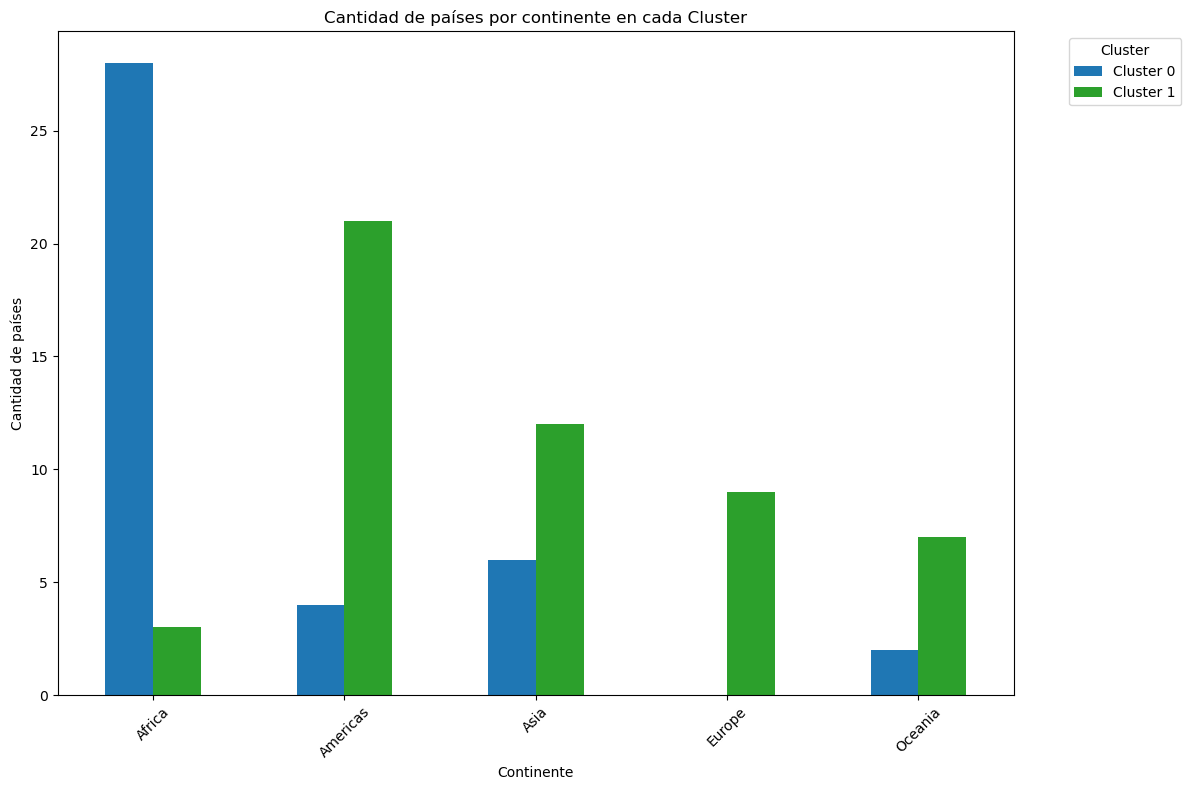

In [10]:
# Contar la cantidad de países por continente en cada cluster
continent_counts = data.groupby(['Continent', 'Cluster'])['CountryName'].nunique().unstack(fill_value=0)

# Definir los colores para los clusters
cluster_colors = {0: '#1f77b4', 1: '#2ca02c'}  # Azul para Cluster 0, Verde para Cluster 1

# Graficar la cantidad de países por continente en cada cluster con barras separadas
ax = continent_counts.plot(kind='bar', figsize=(12, 8), color=[cluster_colors[i] for i in continent_counts.columns])

# Personalizar la gráfica
plt.title('Cantidad de países por continente en cada Cluster')
plt.xlabel('Continente')
plt.ylabel('Cantidad de países')
plt.xticks(rotation=45)  # Girar las etiquetas de los continentes si es necesario
plt.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1'], bbox_to_anchor=(1.05, 1), loc='upper left')  # Poner la leyenda fuera de la gráfica
plt.tight_layout()  # Ajustar el espacio para que la leyenda no se corte
plt.show()


# Algoritmos de predicción
Se utilizan para cada uno de las enfermedades y para la prevalencia total de todas ellas.

### 1. **Random Forest Regressor (RandomForest)**
   **Definición:** Random Forest es un conjunto de árboles de decisión que se entrenan con diferentes subconjuntos del conjunto de datos y características. El modelo final es el promedio de las predicciones de todos los árboles.
   
   **¿Por qué se utilizó?**: Random Forest es muy robusto para manejar datos con interacciones no lineales entre las variables y es menos propenso a sobreajustarse que otros modelos. Además, es adecuado para trabajar con un gran número de características y puede manejar datos faltantes de manera efectiva.

### 2. **Gradient Boosting Machine (GBM)**
   **Definición:** Gradient Boosting es un algoritmo de *ensemble* que crea un modelo fuerte combinando varios modelos débiles (generalmente árboles de decisión) entrenados de manera secuencial. Cada nuevo modelo corrige los errores de los modelos anteriores.
   
   **¿Por qué se utilizó?**: El Gradient Boosting es eficaz cuando se trabaja con datos complejos, y tiene un buen rendimiento incluso con un número relativamente pequeño de árboles. Además, es muy eficaz para predecir patrones no lineales en los datos y puede ofrecer una gran precisión.

### 3. **Support Vector Machine (SVM)**
   **Definición:** Las máquinas de vectores de soporte (SVM) son modelos que buscan una frontera (hiperplano) para separar las diferentes clases o predecir valores de manera continua. El modelo optimiza la posición de ese hiperplano para minimizar los errores de clasificación o predicción.
   
   **¿Por qué se utilizó?**: SVM es muy efectivo en espacios de características de alta dimensión y para problemas con márgenes de separación claros. También es capaz de manejar tanto problemas lineales como no lineales con el uso de diferentes núcleos (kernels).

### 4. **K-Nearest Neighbors (KNN)**
   **Definición:** KNN es un algoritmo basado en la proximidad: para predecir el valor de una nueva instancia, busca los K puntos más cercanos en los datos de entrenamiento y hace la predicción en función de la media (para regresión) o la mayoría de votos (para clasificación) de esos puntos cercanos.
   
   **¿Por qué se utilizó?**: KNN es un algoritmo simple y fácil de entender que no hace suposiciones sobre la distribución de los datos. Es útil cuando las relaciones en los datos son locales y no se requieren modelos muy complejos.

### 5. **Neural Networks (MLPRegressor)**
   **Definición:** Las redes neuronales multilayer perceptron (MLP) son modelos compuestos por capas de neuronas que se conectan entre sí. Cada neurona recibe entradas, las procesa y produce una salida. Las redes neuronales pueden modelar relaciones complejas y no lineales.
   
   **¿Por qué se utilizó?**: Las redes neuronales son potentes cuando se trabaja con datos complejos y tienen la capacidad de modelar patrones no lineales. Son especialmente útiles en tareas de predicción en las que las relaciones entre las características y las respuestas no son triviales.

### **Uso de estos algoritmos**
La razón de utilizar estos algoritmos es que cubren una variedad de enfoques y metodologías para abordar diferentes características y tipos de datos:
- **Random Forest** y **Gradient Boosting** son ideales para manejar datos no lineales y relaciones complejas, lo que los hace adecuados para las enfermedades mentales, donde las interacciones entre los factores pueden no ser simples.
- **SVM** y **KNN** son modelos más simples y pueden ser efectivos en casos donde las relaciones no son extremadamente complejas.
- **Redes Neuronales** (MLP) ofrecen una aproximación de aprendizaje profundo que puede modelar patrones complejos de manera más flexible.

Este enfoque múltiple permite comparar cómo cada modelo se ajusta a los datos y proporciona una evaluación completa del rendimiento del modelo para cada variable objetivo (enfermedad).


In [11]:
 def cross_validate_model(X, y, model, cv=5):
    """
    Calcula RMSE y R² mediante validación cruzada.
    """
    # Definir el scoring para RMSE y R²
    rmse_scorer = make_scorer(mean_squared_error, squared=False)  # False para RMSE
    rmse_scores = cross_val_score(model, X, y, cv=cv, scoring=rmse_scorer)
    r2_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')

    return rmse_scores.mean(), r2_scores.mean()

def train_and_cross_validate_models(df, target_column, cv=5):
    """
    Entrena y evalúa múltiples modelos (Random Forest, GBM, SVM, KNN, NN) con validación cruzada.
    """
    X = df.drop(columns=target_variables + ['CountryName'])
    y = df[target_column]

    models = {
        'RandomForest': RandomForestRegressor(random_state=42),
        'GBM': GradientBoostingRegressor(random_state=42),
        'SVM': SVR(),
        'KNN': KNeighborsRegressor(),
        'NeuralNetwork': Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPRegressor(
                hidden_layer_sizes=(100, 50),
                activation='relu',
                solver='adam',
                learning_rate_init=0.001,
                max_iter=500,
                random_state=42
            ))
        ])
    }

    results = {}
    feature_importances = {model_name: {} for model_name in models}  # Almacenar importancias por modelo y por target
    trained_models = {}  # Diccionario para guardar los modelos entrenados

    for model_name, model in models.items():
        # Validación cruzada
        rmse, r2 = cross_validate_model(X, y, model, cv=cv)
        results[model_name] = {'RMSE': rmse, 'R²': r2}

        # Si el modelo tiene la propiedad 'feature_importances_', almacenamos las importancias
        if hasattr(model, 'feature_importances_'):
            feature_importances[model_name][target_column] = model.feature_importances_

        # Entrenar el modelo final y almacenarlo
        model.fit(X, y)
        trained_models[model_name] = model

    return results, feature_importances, trained_models

cross_validation_results = {}
feature_importances_all = {}
trained_models_all = {}

for target in target_variables:
    results, feature_importances, trained_models = train_and_cross_validate_models(data_cleaned, target)
    cross_validation_results[target] = results
    feature_importances_all[target] = feature_importances
    trained_models_all[target] = trained_models

In [12]:
# Crear la tabla en formato requerido
rows = []
for target, metrics in cross_validation_results.items():
    # Añadir una fila para RMSE
    row_rmse = {'Metric': 'RMSE', 'Disease': target}
    for model, results in metrics.items():
        row_rmse[model] = results['RMSE']
    rows.append(row_rmse)
    
    # Añadir una fila para R²
    row_r2 = {'Metric': 'R²', 'Disease': target}
    for model, results in metrics.items():
        row_r2[model] = results['R²']
    rows.append(row_r2)

# Crear un DataFrame final con la tabla organizada
final_cv_df = pd.DataFrame(rows)
final_cv_df = final_cv_df.set_index(['Disease', 'Metric'])

# Función para resaltar mejores valores en la tabla
def highlight_best_cv_method(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    
    for disease in df.index.get_level_values(0).unique():
        df_subset = df.loc[disease]  # Subset por enfermedad
        
        if 'RMSE' in df_subset.index:
            rmse_row = df_subset.loc['RMSE']
            min_model = rmse_row.idxmin()
            styles.loc[(disease, 'RMSE'), min_model] = 'background-color: #A8D5BA'
        
        if 'R²' in df_subset.index:
            r2_row = df_subset.loc['R²']
            max_model = r2_row.idxmax()
            styles.loc[(disease, 'R²'), max_model] = 'background-color: #A8D5BA'
    
    return styles

# Aplicar resaltado
styled_cv_df = final_cv_df.style.apply(highlight_best_cv_method, axis=None)

# Mostrar la tabla estilizada
styled_cv_df